# HW 6: Study Gini Index

## **WISIT SUWANNAO 67070501042**

Instructions
- Study Gini Index
- Compute the toy example using Gini Index
- Change criterion in the imported library, using Gini Index
- Compare Gini Index vs Entropy
- Use another dataset (datasets.csv)
- Play with parameters:
    - max_depth
    - min_samples_split
    - min_samples_leaf
- Explain your understanding after trying these different parameters


### 1. Study Gini Index

**Gini Index** (or Gini Impurity) is a metric used to measure how often a randomly chosen element from the set would be incorrectly labeled if it was randomly labeled according to the distribution of labels in the subset.

Formula:
$$ Gini(D) = 1 - \sum_{i=1}^{c} (p_i)^2 $$

Where $p_i$ is the probability of an item being classified to a particular class.

Gini Index ranges between 0 and 0.5 (for binary classification):
- **0**: Pure node (all elements belong to the same class).
- **0.5**: Impure node (elements are distributed equally across classes).

The Gini Index is computationally faster than Entropy because it doesn't involve logarithmic functions. It is the default criterion for the CART (Classification and Regression Trees) algorithm used by Scikit-Learn.

### 2. Compute the toy example using Gini Index

Let's compute the Gini Index for the given `toy_data.csv`.

In [ ]:
import pandas as pd
import numpy as np

# Load the toy dataset
df_toy = pd.read_csv('toy_data.csv')

# Display the dataframe
df_toy

,age,income,student,credit rating,buys computer
0,<=30,high,no,fair,no
1,<=30,high,no,excellent,no
2,31-40,high,no,fair,yes
3,>40,medium,no,fair,yes
4,>40,low,yes,fair,yes
5,>40,low,yes,excellent,no
6,31-40,low,yes,excellent,yes
7,<=30,medium,no,fair,no
8,<=30,low,yes,fair,yes
9,>40,medium,yes,fair,yes


In [ ]:
def gini_index(target_col):
    """
    Calculate the Gini Index of a dataset.
    """
    elements, counts = np.unique(target_col, return_counts=True)
    impurity = 1
    sum_counts = np.sum(counts)
    for i in range(len(elements)):
        prob = counts[i] / sum_counts
        impurity -= prob**2
    return impurity

def gini_gain(data, split_attribute_name, target_name="buys computer"):
    """
    Calculate the Gini Gain of a dataset.
    This is typically Information Gain based on Gini Index impurity reduction.
    """
    # Calculate the Gini Index of the total dataset
    total_gini = gini_index(data[target_name])

    # Calculate the values and the counts for the split attribute
    vals, counts = np.unique(data[split_attribute_name], return_counts=True)

    # Calculate the weighted Gini Index
    weighted_gini = 0
    sum_counts = np.sum(counts)
    for i in range(len(vals)):
        prob = counts[i] / sum_counts

        # Filter the data for the specific value
        filtered_data = data[data[split_attribute_name] == vals[i]]

        # Calculate weighted Gini
        weighted_gini += prob * gini_index(filtered_data[target_name])

    # Calculate the Gini Gain (Reduction in Impurity)
    gain = total_gini - weighted_gini
    return gain

# Calculate Gini Index for the target column
print(f"Gini Index of dataset (buys computer): {gini_index(df_toy['buys computer']):.4f}")

# Calculate Gini Gain for each feature to decide the best split
features = ['age', 'income', 'student', 'credit rating']
print("\nGini Gain for each feature:")
for feature in features:
    gain = gini_gain(df_toy, feature)
    print(f"{feature}: {gain:.4f}")

Gini Index of dataset (buys computer): 0.4592

Gini Gain for each feature:
age: 0.1163
income: 0.0187
student: 0.0918
credit rating: 0.0306


### 3. Change criterion in the imported library, using Gini Index

Now we will use `scikit-learn` to build a Decision Tree using `criterion='gini'`.
First, we need to preprocess the data using Label Encoding.

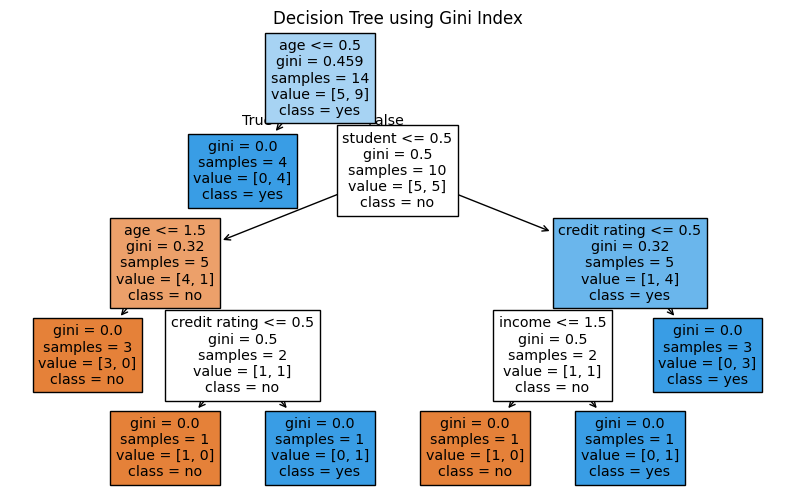

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt

# Preprocessing: Encode categorical variables
df_encoded = df_toy.copy()
label_encoder = LabelEncoder()

for col in df_encoded.columns:
    df_encoded[col] = label_encoder.fit_transform(df_encoded[col])

# Define X and y
X = df_encoded.drop('buys computer', axis=1)
y = df_encoded['buys computer']

# Create Decision Tree Classifier with Gini Index
clf_gini = DecisionTreeClassifier(criterion='gini', random_state=42)
clf_gini.fit(X, y)

# Visualize the Tree
plt.figure(figsize=(10, 6))
plot_tree(clf_gini, filled=True, feature_names=df_toy.columns[:-1], class_names=['no', 'yes'])
plt.title("Decision Tree using Gini Index")
plt.show()

### 4. Compare Gini Index vs Entropy

Let's train another model using **Entropy** for comparison.

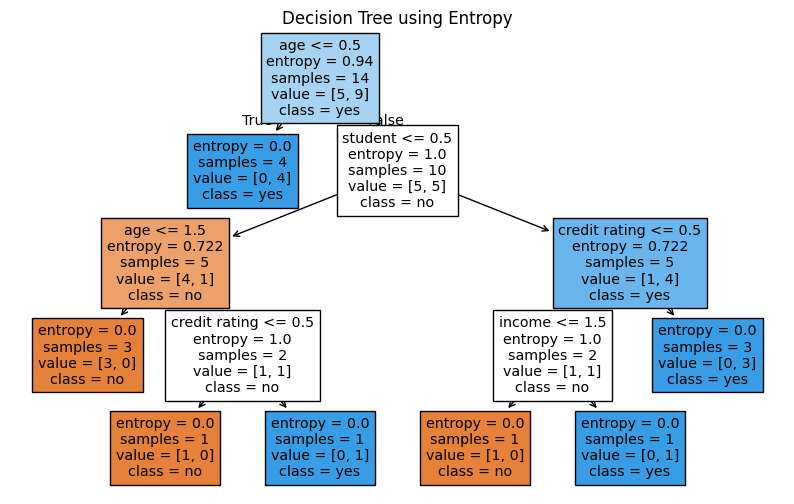

In [ ]:
# Create Decision Tree Classifier with Entropy
clf_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)
clf_entropy.fit(X, y)

# Visualize the Tree
plt.figure(figsize=(10, 6))
plot_tree(clf_entropy, filled=True, feature_names=df_toy.columns[:-1], class_names=['no', 'yes'])
plt.title("Decision Tree using Entropy")
plt.show()

**Comparison: Gini Index vs Entropy**

*   **Structure**: In many cases, the resulting tree structure is identical or very similar. In this toy example, we can observe if the splits and depth differ.
*   **Computation**: Gini Index is generally computationally faster because it doesn't require calculating logarithms like Entropy does.
*   **Preference**: Gini tends to isolate the most frequent class in its own branch of the tree, while Entropy tends to produce slightly more balanced trees.
*   **Performance**: In practice, the difference in accuracy between Gini and Entropy is usually negligible (often less than 2%).

### 5. Use another dataset (`dataset.csv`)

We will now apply Decision Tree classification to a larger dataset (`dataset.csv`).

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Load the dataset
df_dataset = pd.read_csv('dataset.csv')

# Display first few rows
print(df_dataset.head())

# Features and Target
X_new = df_dataset.drop('target', axis=1)
y_new = df_dataset['target']

# Split the dataset (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X_new, y_new, test_size=0.2, random_state=42)

print(f"Training Data Shape: {X_train.shape}")
print(f"Testing Data Shape: {X_test.shape}")

   feature_0  feature_1  feature_2  feature_3  feature_4  target
0   0.374540   0.950714   0.731994   0.598658   0.156019       0
1   0.155995   0.058084   0.866176   0.601115   0.708073       1
2   0.020584   0.969910   0.832443   0.212339   0.181825       1
3   0.183405   0.304242   0.524756   0.431945   0.291229       0
4   0.611853   0.139494   0.292145   0.366362   0.456070       1
Training Data Shape: (120, 5)
Testing Data Shape: (30, 5)


### 6. Play with parameters

We will experiment with:
- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

We create a function to train and evaluate the model with different parameters.

In [ ]:
def train_and_evaluate(max_depth=None, min_samples_split=2, min_samples_leaf=1):
    clf = DecisionTreeClassifier(
        criterion='gini',
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_train_pred = clf.predict(X_train)
    y_test_pred = clf.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    print(f"Params: max_depth={max_depth}, min_samples_split={min_samples_split}, min_samples_leaf={min_samples_leaf}")
    print(f"  Training Accuracy: {train_acc:.4f}")
    print(f"  Testing Accuracy:  {test_acc:.4f}")
    print("-" * 50)
    return clf

print("--- Experimenting with max_depth ---")
train_and_evaluate(max_depth=1)
train_and_evaluate(max_depth=3)
train_and_evaluate(max_depth=5)
train_and_evaluate(max_depth=None)

print("\n--- Experimenting with min_samples_split ---")
train_and_evaluate(max_depth=5, min_samples_split=2)
train_and_evaluate(max_depth=5, min_samples_split=10)
train_and_evaluate(max_depth=5, min_samples_split=50)

print("\n--- Experimenting with min_samples_leaf ---")
train_and_evaluate(max_depth=5, min_samples_leaf=1)
train_and_evaluate(max_depth=5, min_samples_leaf=5)
train_and_evaluate(max_depth=5, min_samples_leaf=20)

--- Experimenting with max_depth ---
Params: max_depth=1, min_samples_split=2, min_samples_leaf=1
  Training Accuracy: 0.6583
  Testing Accuracy:  0.5667
--------------------------------------------------
Params: max_depth=3, min_samples_split=2, min_samples_leaf=1
  Training Accuracy: 0.8417
  Testing Accuracy:  0.7667
--------------------------------------------------
Params: max_depth=5, min_samples_split=2, min_samples_leaf=1
  Training Accuracy: 0.9417
  Testing Accuracy:  0.7333
--------------------------------------------------
Params: max_depth=None, min_samples_split=2, min_samples_leaf=1
  Training Accuracy: 1.0000
  Testing Accuracy:  0.8000
--------------------------------------------------

--- Experimenting with min_samples_split ---
Params: max_depth=5, min_samples_split=2, min_samples_leaf=1
  Training Accuracy: 0.9417
  Testing Accuracy:  0.7333
--------------------------------------------------
Params: max_depth=5, min_samples_split=10, min_samples_leaf=1
  Training A

DecisionTreeClassifier(max_depth=5, min_samples_leaf=20, random_state=42)

### 7. Explain your understanding after trying these different parameters

**Explanation of Results:**

1.  **`max_depth` (Maximum Depth of the Tree):**
    *   **Observation:** As `max_depth` increases, training accuracy typically increases because the model can capture more complex patterns. However, if it's too deep (e.g., `None`), the model might overfit (memorize the training data), leading to a high training accuracy but potentially lower testing accuracy compared to an optimal depth.
    *   **Conclusion:** Controlling depth helps prevent overfitting. A shallow tree (low `max_depth`) might underfit.

2.  **`min_samples_split` (Minimum Samples required to Split):**
    *   **Observation:** Increasing this value prevents the tree from creating nodes for very specific small groups of data.
    *   **Conclusion:** Higher values constrain the tree growth (regularization), which can reduce overfitting but might also lead to underfitting if set too high.

3.  **`min_samples_leaf` (Minimum Samples required at a Leaf Node):**
    *   **Observation:** This parameter ensures that every leaf has at least a certain number of samples.
    *   **Conclusion:** Similar to `min_samples_split`, increasing this value smooths the model, making it more robust to noise and outliers in the training data. It effectively "prunes" the tree by not allowing very specific leaves.

**Overall Understanding:**

Hyperparameters like `max_depth`, `min_samples_split`, and `min_samples_leaf` are crucial for controlling the **bias-variance tradeoff**.
-   **Too flexible (Deep tree, low min samples):** High Variance (Overfitting). Fits training data perfectly but fails on new data.
-   **Too rigid (Shallow tree, high min samples):** High Bias (Underfitting). Fails to capture the underlying pattern.

Finding the right balance (e.g., through Grid Search) is key to building a good predictive model.